
---

# 🔄 **`FunctionTransformer & Feature Transformations in Python (Log, Reciprocal, Square Root Transformations)`**
  
**Feature transformation** is a critical step in **Machine Learning (ML)** and **Data Science** to handle skewed data, improve model performance, and make distributions more normal-like. **FunctionTransformer** in `sklearn.preprocessing` allows us to apply **custom transformations** seamlessly.

---

## ✅ **1. Why Use Feature Transformations?**
✔ **Reduces Skewness** → Helps normalize distributions.  
✔ **Stabilizes Variance** → Important for **Linear Regression, PCA, LDA**.  
✔ **Enhances Interpretability** → Log transformations make **multiplicative** relationships **additive**.  
✔ **Improves Model Performance** → Helps some algorithms perform better.  

---

## 📊 **2. FunctionTransformer in Scikit-Learn**
**`FunctionTransformer`** allows you to apply **any mathematical transformation** (e.g., Log, Square Root, Reciprocal) to features.

### ✍️ **Example: Applying Log Transform Using `FunctionTransformer`**

In [87]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import FunctionTransformer

# Sample Data
df = pd.DataFrame({'Salary': [2000, 5000, 10000, 20000, 50000]})

# Define Log Transform
log_transformer = FunctionTransformer(np.log1p)  # log1p to handle zeros (log(1 + x))

# Apply Transformation
df['Log_Salary'] = log_transformer.transform(df[['Salary']])

print(df)

   Salary  Log_Salary
0    2000    7.601402
1    5000    8.517393
2   10000    9.210440
3   20000    9.903538
4   50000   10.819798


**💡 Why `log1p(x)` instead of `log(x)`?**  
- `log1p(x) = log(1 + x)` avoids issues when `x = 0`.

---

## 📉 **3. Log Transformation**
### **🔹 When to Use Log Transform?**
✅ **For Right-Skewed Data** (e.g., Income, Sales, Population).  
✅ **Reduces impact of outliers** (brings extreme values closer to the mean).  
✅ **Improves model interpretability** (turns multiplicative relationships into additive ones).  
❌ **Avoid for Negative/Zero values** (Use `log1p()` instead of `log()`).

### **✍️ Example: Manual Log Transformation**

In [88]:
df['Log_Salary'] = np.log1p(df['Salary'])


🔹 **Before & After Log Transform Visualization**

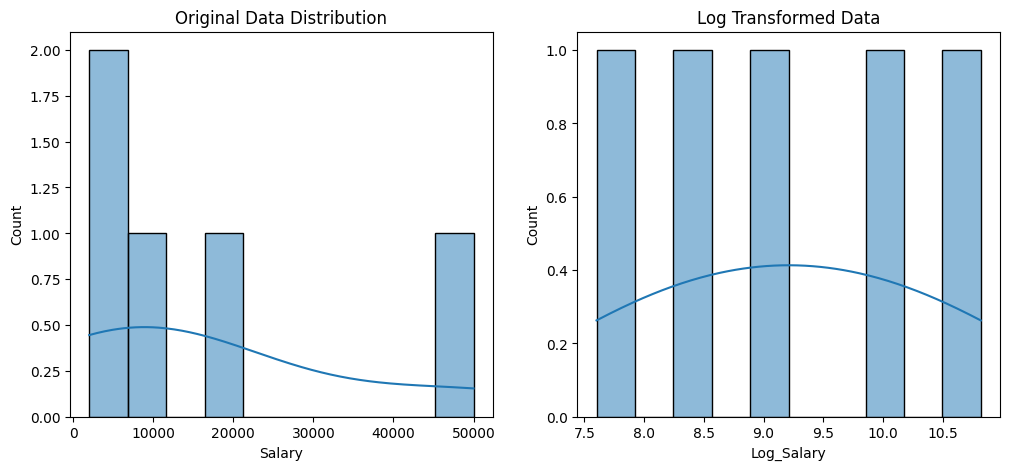

In [89]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['Salary'], bins=10, kde=True, ax=axes[0])
axes[0].set_title("Original Data Distribution")

sns.histplot(df['Log_Salary'], bins=10, kde=True, ax=axes[1])
axes[1].set_title("Log Transformed Data")

plt.show()

---

## 🔄 **4. Reciprocal Transformation (Inverse Transform)**
**Formula:**  

$
X' = \frac{1}{X}
$

### **🔹 When to Use Reciprocal Transform?**
✅ **For highly skewed data with large values**.  
✅ **Used in financial & physics-based models**.  
❌ **Not defined for `x = 0`** → Need to shift values before applying.  

### **✍️ Example: Applying Reciprocal Transform**

In [90]:

# Define Reciprocal Transform
reciprocal_transformer = FunctionTransformer(lambda x: 1 / (x + 1))  # To avoid division by zero

# Apply Transformation
df['Reciprocal_Salary'] = reciprocal_transformer.transform(df[['Salary']])

print(df)

   Salary  Log_Salary  Reciprocal_Salary
0    2000    7.601402            0.00050
1    5000    8.517393            0.00020
2   10000    9.210440            0.00010
3   20000    9.903538            0.00005
4   50000   10.819798            0.00002


💡 **Notice:**  
- Large values shrink significantly.  
- Can be useful when **handling power-law distributions**.

---

## 📏 **5. Square Root Transformation**
**Formula:** 
 
$
    X' = \sqrt{X}
$

### **🔹 When to Use Square Root Transform?**
✅ **For moderately skewed data** (less extreme than Log Transform).  
✅ **Preserves order of data** (unlike Reciprocal, which flips rankings).  
✅ **Handles zero values well**.  

### **✍️ Example: Applying Square Root Transform**

In [91]:

# Define Square Root Transform
sqrt_transformer = FunctionTransformer(np.sqrt)

# Apply Transformation
df['Sqrt_Salary'] = sqrt_transformer.transform(df[['Salary']])

print(df)

   Salary  Log_Salary  Reciprocal_Salary  Sqrt_Salary
0    2000    7.601402            0.00050    44.721360
1    5000    8.517393            0.00020    70.710678
2   10000    9.210440            0.00010   100.000000
3   20000    9.903538            0.00005   141.421356
4   50000   10.819798            0.00002   223.606798



💡 **Use for data that follows a quadratic relationship**.

---

## 🚀 **6. Using FunctionTransformer in an ML Pipeline**

In [92]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Sample Data
df = pd.DataFrame({'Age': [25, 30, 35, 40, 50], 'Salary': [2000, 5000, 10000, 20000, 50000], 'Purchased': [0, 1, 0, 1, 0]})

# Split dataset
X = df[['Age', 'Salary']]
y = df['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Pipeline with Log Transformation & Scaling
pipeline = Pipeline([
    ('log_transform', FunctionTransformer(np.log1p)),  # Apply Log Transform
    ('scaler', StandardScaler()),  # Apply Standardization
    ('classifier', RandomForestClassifier(n_estimators=100))
])

# Train model
pipeline.fit(X_train, y_train)

# Evaluate model
accuracy = pipeline.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.0


💡 **Ensures consistent transformations for train & test sets**.

---

## 📊 **7. When to Use Each Transformation?**

| **Transformation**     | **Formula**         | **When to Use?**                             | **Avoid If** |
|----------------------|--------------------|-----------------------------------|------------|
| **Log Transform**     | $ X' = \log(X) $ | Right-skewed data, outliers, exponential growth | Negative values |
| **Reciprocal Transform** | $ X' = 1/X $ | Highly skewed data, inverse relationships | Data with zeros |
| **Square Root Transform** | $ X' = \sqrt{X} $ | Mild skewness, stabilizing variance | Extreme outliers |

---

## 🎯 **8. Final Thoughts**
✔ **Feature transformations improve model accuracy & interpretability.**  
✔ **Log Transform is most commonly used for right-skewed data.**  
✔ **Reciprocal Transform flips rankings, useful for power-law distributions.**  
✔ **Square Root Transform is milder than Log, preserving data order.**  
✔ **Always visualize data before & after transformation to check effectiveness.**  

💡 **Pro Tip:** Use `FunctionTransformer()` within `Pipeline()` to automate preprocessing in ML workflows.

---


## ***`Further Practice of Mathematical Transformations`***

- We will implement 4 different transformers using Function Transformer.

#### **Import Libraries**

In [93]:
import os
import pickle
import numpy as np
import pandas as pd 
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


import warnings
warnings.filterwarnings("ignore")

#### **Load the Data**

-  We will only use 3 columns : `'Age','Fare','Survived'`

In [94]:
df = pd.read_csv(
    r"https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day30-function-transformer/train.csv",
    usecols=['Age','Fare','Survived'],
)
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


#### **Impute the Missing Values in `Age` Column**

In [95]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

#### **Seprating `X` and `y`**

- Selects specific columns from the DataFrame

In [96]:
X = df.iloc[:, 1:3]  # Features: selects all rows and the 2nd and 3rd columns (index 1 and 2)
y = df.iloc[:, 0]     # Target variable: selects all rows and the 1st column (index 0)

#### **Splits the dataset into training and testing sets**

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,                # Features
    y,                # Target variable
    test_size=0.2,   # 20% of the data will be used for testing
    random_state=42, # Ensures reproducibility of the split
)

#### **Plot to verify the Normal Distribution**

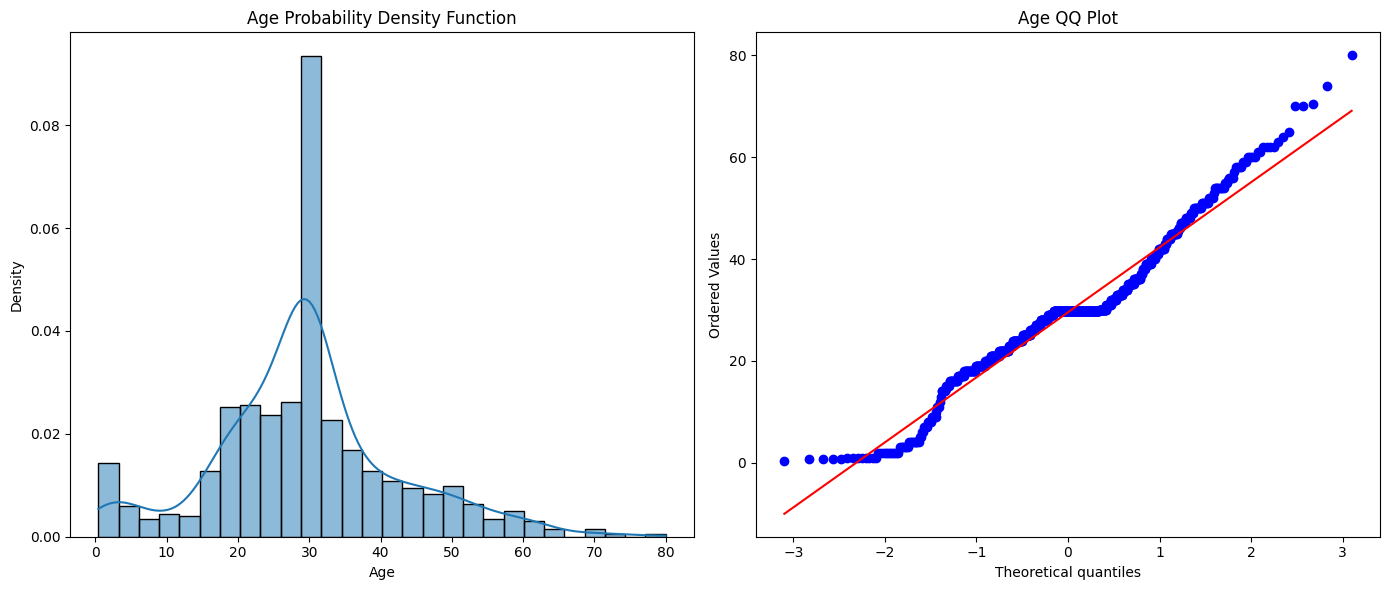

In [98]:
# Set the figure size
plt.figure(figsize=(14, 6))

# Create the first subplot for the distribution plot
plt.subplot(121)
sns.histplot(X_train['Age'], kde=True, stat="density")  # Update to histplot with KDE
plt.title("Age Probability Density Function")

# Create the second subplot for the QQ plot
plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title("Age QQ Plot")

# Show the plots
plt.tight_layout()  # Adjusts subplot parameters for a better fit
plt.show()

- Close to normal distribution

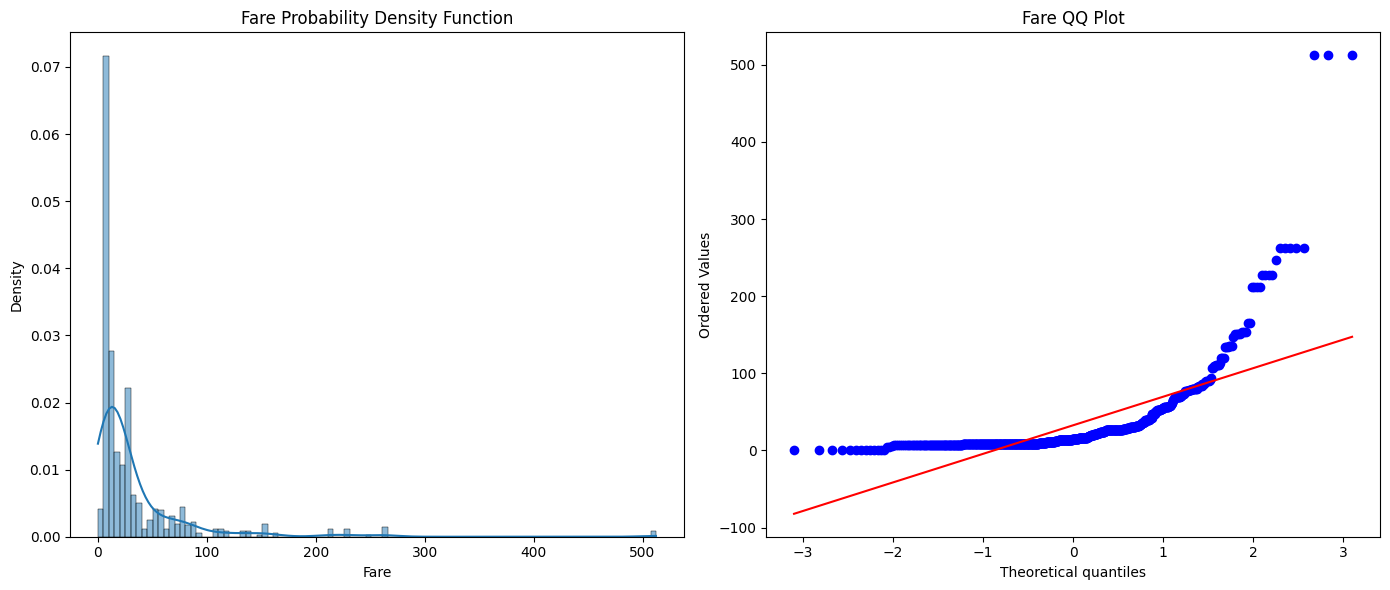

In [99]:
# Set the figure size
plt.figure(figsize=(14, 6))

# Create the first subplot for the distribution plot
plt.subplot(121)
sns.histplot(X_train['Fare'], kde=True, stat="density")  # Update to histplot with KDE
plt.title("Fare Probability Density Function")

# Create the second subplot for the QQ plot
plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title("Fare QQ Plot")

# Show the plots
plt.tight_layout()  # Adjusts subplot parameters for a better fit
plt.show()

- Not Normally Distributed. (`Right Skewed`)
- For this We will use Log Transformation. 

#### **Applying Models on `Without` Transformed Data** 

In [100]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [101]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred2 = clf2.predict(X_test)

print("Accuracy Score of Logistic Regression: ",accuracy_score(y_test,y_pred))
print("Accuracy Score of Decision Tree Classifier :",accuracy_score(y_test,y_pred2))

Accuracy Score of Logistic Regression:  0.6480446927374302
Accuracy Score of Decision Tree Classifier : 0.664804469273743


#### **Applying Models on `With` Transformed Data** 

In [102]:
# Creates a FunctionTransformer that applies the natural logarithm transformation
# (log(1 + x)) to the input data, which is useful for handling skewed data.
trf = FunctionTransformer(func=np.log1p)

In [103]:
X_train_tranformed = trf.fit_transform(X_train)
X_test_tranformed = trf.transform(X_test)

In [104]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [105]:
clf.fit(X_train_tranformed,y_train)
clf2.fit(X_train_tranformed,y_train)

y_pred = clf.predict(X_test_tranformed)
y_pred2 = clf2.predict(X_test_tranformed)

print("Accuracy Score of Logistic Regression With Log Tranformation: ",accuracy_score(y_test,y_pred))
print("Accuracy Score of Decision Tree Classifier With Log Tranformation: ",accuracy_score(y_test,y_pred2))

Accuracy Score of Logistic Regression With Log Tranformation:  0.6815642458100558
Accuracy Score of Decision Tree Classifier With Log Tranformation:  0.6983240223463687


#### **Cross-Validate the `Log Transformed` Results**

In [106]:
X_tranformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("Logistic Regression CV Accuracy: ",np.mean(cross_val_score(clf,X_tranformed,y,scoring='accuracy',cv=10)))
print("Decision Tree CV Accuracy: ",np.mean(cross_val_score(clf2,X_tranformed,y,scoring='accuracy',cv=10)))

Logistic Regression CV Accuracy:  0.678027465667915
Decision Tree CV Accuracy:  0.6621847690387016


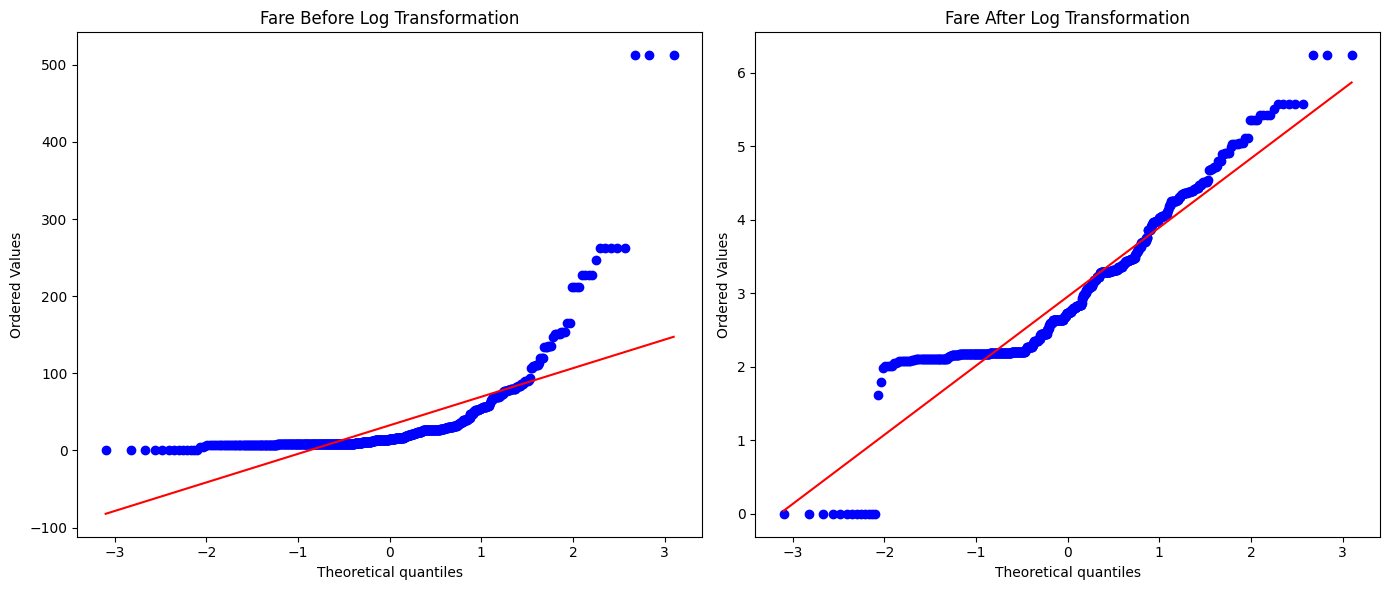

In [107]:
# Set the figure size
plt.figure(figsize=(14, 6))

# Create the first subplot for the distribution plot
plt.subplot(121)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title("Fare Before Log Transformation")

# Create the second subplot for the QQ plot
plt.subplot(122)
stats.probplot(X_train_tranformed['Fare'], dist='norm', plot=plt)
plt.title("Fare After Log Transformation")

# Show the plots
plt.tight_layout()  # Adjusts subplot parameters for a better fit
plt.show()

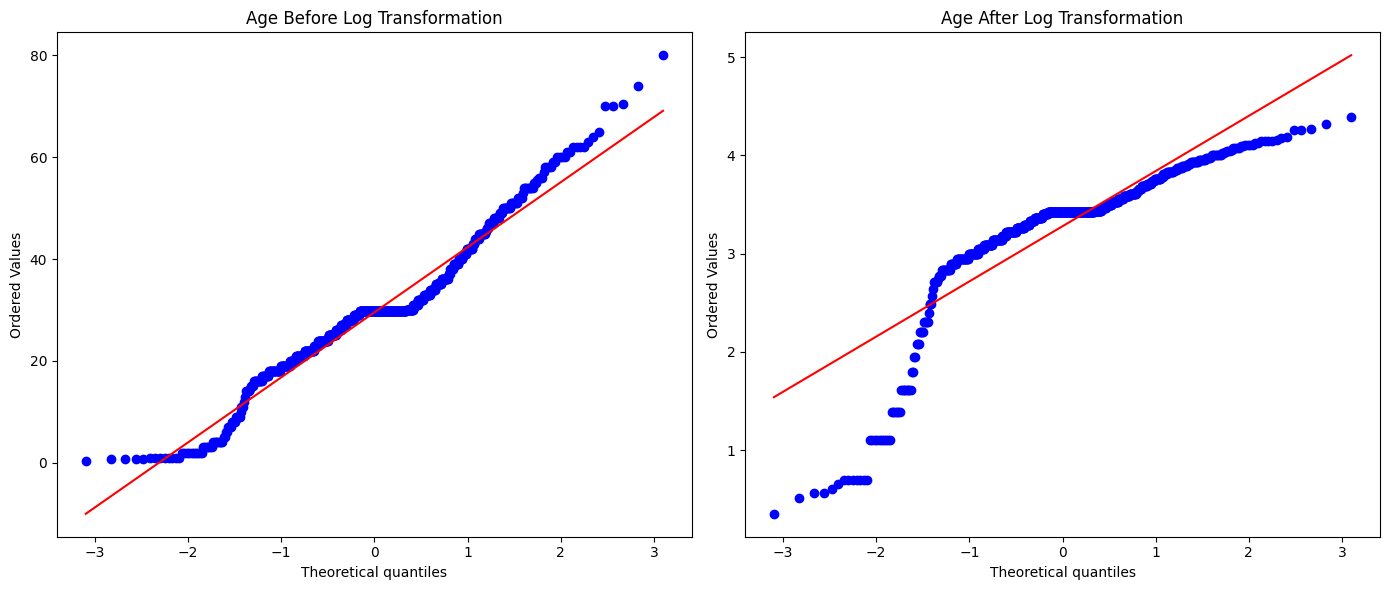

In [108]:
# Set the figure size
plt.figure(figsize=(14, 6))

# Create the first subplot for the distribution plot
plt.subplot(121)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title("Age Before Log Transformation")

# Create the second subplot for the QQ plot
plt.subplot(122)
stats.probplot(X_train_tranformed['Age'], dist='norm', plot=plt)
plt.title("Age After Log Transformation")

# Show the plots
plt.tight_layout()  # Adjusts subplot parameters for a better fit
plt.show()

- We can see result's are little disappointing.
- Transformation disturbed distribution.

In [109]:
# Creates a ColumnTransformer that applies the natural logarithm transformation
# (log(1 + x)) to the 'Fare' column while leaving all other columns unchanged.
trf2 = ColumnTransformer(
    [('log', FunctionTransformer(np.log1p), ['Fare'])],  # Transformation applied to 'Fare'
    remainder='passthrough'  # Other columns are retained without transformation
)

X_train_tranformed2 = trf.fit_transform(X_train)
X_test_tranformed2 = trf.transform(X_test)

In [110]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_tranformed2,y_train)
clf2.fit(X_train_tranformed2,y_train)

y_pred = clf.predict(X_test_tranformed2)
y_pred2 = clf2.predict(X_test_tranformed2)

print("Logistic Regression Accuracy: ",accuracy_score(y_test,y_pred2))
print("Decision Tree Accuracy: ",accuracy_score(y_test,y_pred2))

Logistic Regression Accuracy:  0.6759776536312849
Decision Tree Accuracy:  0.6759776536312849


In [111]:
X_tranformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("Logistic Regression CV Accuracy: ",np.mean(cross_val_score(clf,X_tranformed2,y,scoring='accuracy',cv=10)))
print("Decision Tree CV Accuracy: ",np.mean(cross_val_score(clf2,X_tranformed2,y,scoring='accuracy',cv=10)))

Logistic Regression CV Accuracy:  0.6712609238451936
Decision Tree CV Accuracy:  0.6554556803995005


In [112]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6589013732833957


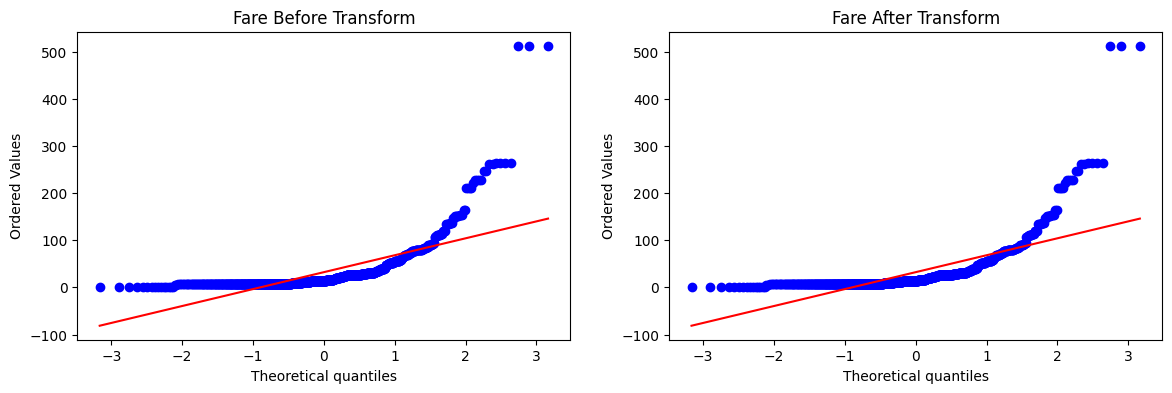

In [113]:
apply_transform(lambda x : x)

Accuracy 0.6431335830212235


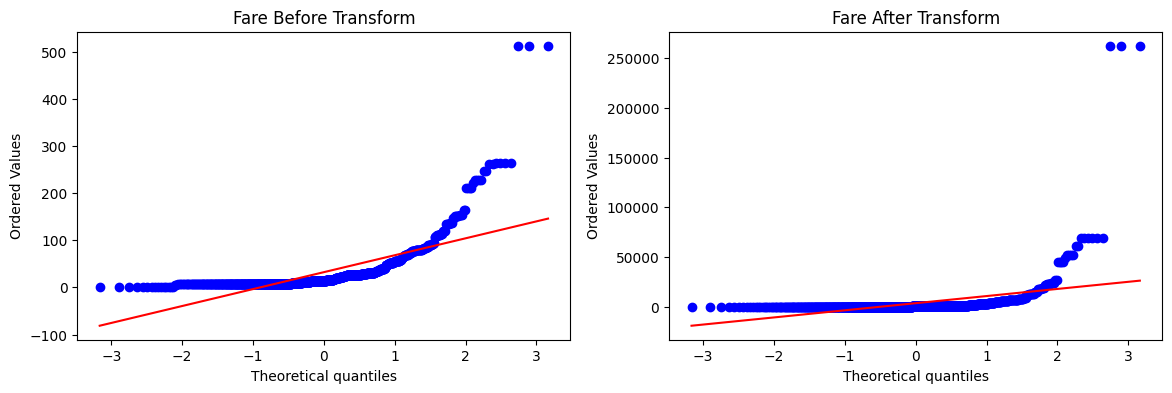

In [114]:
apply_transform(lambda x : x**2)

- Resultt getting worse

Accuracy 0.6195131086142323


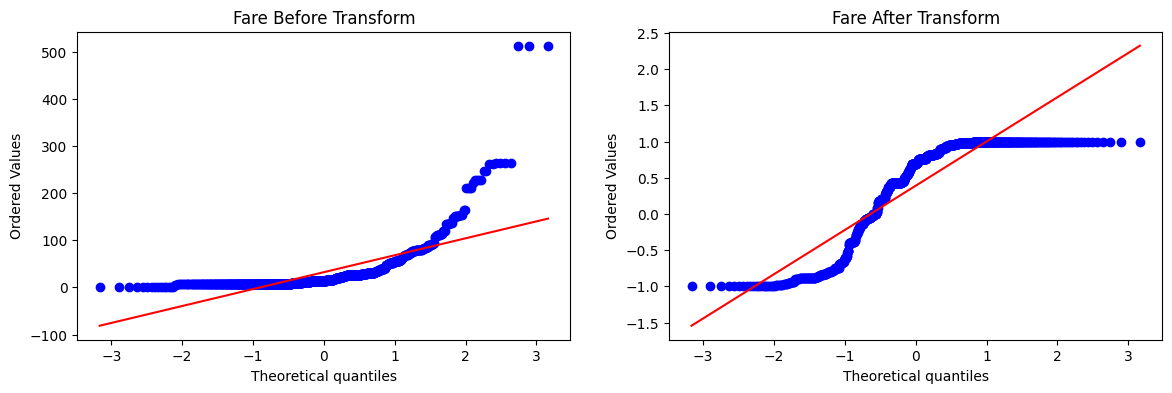

In [115]:
apply_transform(np.sin)

---